In [2]:
# Install libraries

!pip install transformers datasets evaluate scikit-learn matplotlib pandas
!pip install kaggle
!pip install kagglehub



In [3]:
!pip install torch

In [4]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA GeForce RTX 3070 Laptop GPU


In [5]:
# Import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

C:\Users\jess\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Kaggle setup
!kaggle datasets download -d andrewmvd/trip-advisor-hotel-reviews
import zipfile

with zipfile.ZipFile("trip-advisor-hotel-reviews.zip", 'r') as zip_ref:
        zip_ref.extractall()
    

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
trip-advisor-hotel-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
# Download TripAdvisor data now
!kaggle datasets download -d andrewmvd/trip-advisor-hotel-reviews

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
trip-advisor-hotel-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)


In [8]:
#Downloading IMDB dataset

from datasets import load_dataset

imdb = load_dataset("imdb")
imdb_train = pd.DataFrame(imdb["train"])
imdb_test = pd.DataFrame(imdb["test"])

Step 2:

Exploratory Data Analysis of the two datasets.

This is so we can understand what we are working with.

In [9]:
#Intial investigation of Trip Advisor dataset:

# Checking collumns, labels

# Unzip the TripAdvisor dataset
!unzip -o /content/trip-advisor-hotel-reviews.zip

# Load the data into a pandas DataFrame
trip_df = pd.read_csv('tripadvisor_hotel_reviews.csv')


print(trip_df.columns)
print(trip_df.shape)
print(trip_df["Rating"].value_counts().sort_index())
trip_df.head()

'unzip' is not recognized as an internal or external command,
operable program or batch file.


Index(['Review', 'Rating'], dtype='object')
(20491, 2)
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


Index(['text', 'label'], dtype='object')
(25000, 2)
                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


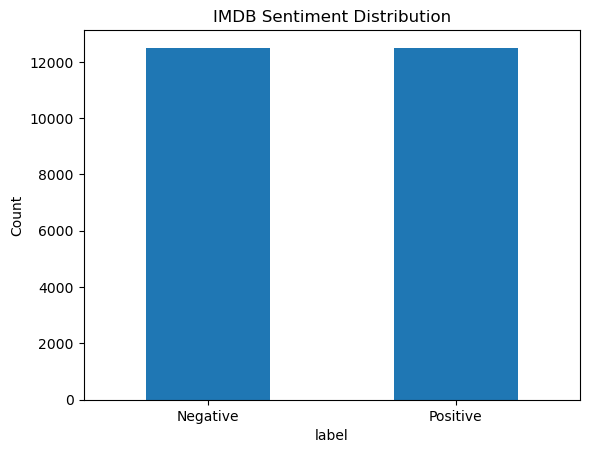

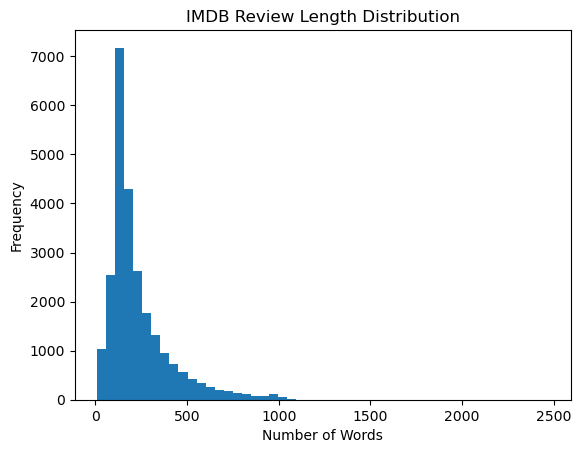

count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: review_length, dtype: float64

In [10]:
# Intial investigation of the IMDB dataset
print(imdb_train.columns)
print(imdb_train.shape)
print(imdb_train.head())

# Visualisation distribution
imdb_train["label"].value_counts().plot(kind="bar")
plt.title("IMDB Sentiment Distribution")
plt.xticks([0,1], ["Negative","Positive"], rotation=0)
plt.ylabel("Count")
plt.show()

# Review length
imdb_train["review_length"] = imdb_train["text"].apply(lambda x: len(x.split()))

plt.hist(imdb_train["review_length"], bins=50)
plt.title("IMDB Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()
imdb_train["review_length"].describe()

Step 3:
Cleaning the data for analysis.

In [11]:
# Can see above that the TripAdvisor reviews are 1-5, we need this to be binary to compare with the IMDB reviews.
# Now we will change this to be ratings 1-2 = negative, 3 = removed and finally, 4-5 = positive.

trip_df = trip_df[trip_df["Rating"] != 3].copy()
trip_df["label"] = trip_df["Rating"].apply(lambda x: 1 if x >= 4 else 0)
trip_df = trip_df.rename(columns={"Review": "text"})
trip_df = trip_df[["text", "label"]]
print(trip_df["label"].value_counts())

label
1    15093
0     3214
Name: count, dtype: int64


In [12]:
# Now we must ensure the data is seperated into train, test and validation sets.
# For IMDB:

imdb_train_df, imdb_val_df = train_test_split(
    imdb_train,
    test_size=0.1,
    stratify=imdb_train["label"],
    random_state=42
)

# And for TripAdvisor:
trip_train, trip_temp = train_test_split(
    trip_df,
    test_size=0.2,
    stratify=trip_df["label"],
    random_state=42
)

trip_val, trip_test = train_test_split(
    trip_temp,
    test_size=0.5,
    stratify=trip_temp["label"],
    random_state=42
)

# Check the splits:
print("IMDB train:", imdb_train_df.shape)
print("IMDB val:", imdb_val_df.shape)
print("IMDB test:", imdb_test.shape)

print("\nTripAdvisor train:", trip_train.shape)
print("TripAdvisor val:", trip_val.shape)
print("TripAdvisor test:", trip_test.shape)

print("\nTripAdvisor train labels:")
print(trip_train["label"].value_counts())

print("\nTripAdvisor val labels:")
print(trip_val["label"].value_counts())

print("\nTripAdvisor test labels:")
print(trip_test["label"].value_counts())

IMDB train: (22500, 3)
IMDB val: (2500, 3)
IMDB test: (25000, 2)

TripAdvisor train: (14645, 2)
TripAdvisor val: (1831, 2)
TripAdvisor test: (1831, 2)

TripAdvisor train labels:
label
1    12074
0     2571
Name: count, dtype: int64

TripAdvisor val labels:
label
1    1510
0     321
Name: count, dtype: int64

TripAdvisor test labels:
label
1    1509
0     322
Name: count, dtype: int64


The IMDB dataset provides predefined training and test sets. A validation set containing 10% of the training data was created using stratified sampling to maintain class balance.

Unlike the IMDB dataset, which is balanced between positive and negative reviews, the TripAdvisor dataset exhibits class imbalance, with a substantially higher proportion of positive reviews. This difference may influence classification performance and is considered when analysing model results.

In [13]:
# Can also see that above, there are three collumns in the IMDB dataframe. This probably happened during the exploratory data stage. This needs resolved first:

imdb_train_df = imdb_train_df[["text","label"]]
imdb_val_df = imdb_val_df[["text","label"]]
imdb_test = imdb_test[["text","label"]]

In [14]:
#Dataset Conversion for Transformer Models
imdb_ds = DatasetDict({
    "train": Dataset.from_pandas(imdb_train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(imdb_val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(imdb_test.reset_index(drop=True))
})

trip_ds = DatasetDict({
    "train": Dataset.from_pandas(trip_train.reset_index(drop=True)),
    "validation": Dataset.from_pandas(trip_val.reset_index(drop=True)),
    "test": Dataset.from_pandas(trip_test.reset_index(drop=True))
})

In [15]:
# Add in metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [16]:
# Add in resuseable training function:

def run_experiment(model_name, dataset_dict, experiment_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=256
        )

    tokenized_ds = dataset_dict.map(tokenize_function, batched=True)
    tokenized_ds = tokenized_ds.remove_columns(["text"])
    tokenized_ds.set_format("torch")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f"./{experiment_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=2,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        save_total_limit=1,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["validation"],
        compute_metrics=compute_metrics
    )

    trainer.train()
    test_results = trainer.predict(tokenized_ds["test"])

    return trainer, test_results

In [17]:
# Running one to test if it is working before running all four:

bert_imdb_trainer, bert_imdb_results = run_experiment(
    "bert-base-uncased",
    imdb_ds,
    "bert_imdb"
)

bert_imdb_results.metrics

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1585.95it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider tr

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.326245,0.280438,0.912000,0.891337,0.938400,0.914263
2,0.174744,0.327338,0.922400,0.920382,0.924800,0.922586


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.63it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

{'test_loss': 0.3181290626525879,
 'test_accuracy': 0.92196,
 'test_precision': 0.9174515235457064,
 'test_recall': 0.92736,
 'test_f1': 0.9223791525760892,
 'test_runtime': 359.44,
 'test_samples_per_second': 69.553,
 'test_steps_per_second': 8.694}

In [18]:
# Add in reusable training function

def run_experiment(model_name, dataset_dict, experiment_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=256
        )

    tokenized_ds = dataset_dict.map(tokenize_function, batched=True)
    tokenized_ds = tokenized_ds.remove_columns(["text"])
    tokenized_ds.set_format("torch")

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    training_args = TrainingArguments(
        output_dir=f"./{experiment_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=2e-5,

        # GPU improvements
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        fp16=True,

        num_train_epochs=2,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        save_total_limit=1,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_ds["train"],
        eval_dataset=tokenized_ds["validation"],
        compute_metrics=compute_metrics
    )

    trainer.train()

    test_results = trainer.predict(tokenized_ds["test"])

    return trainer, test_results

In [19]:
roberta_imdb_trainer, roberta_imdb_results = run_experiment(
    "roberta-base",
    imdb_ds,
    "roberta_imdb"
)

roberta_imdb_results.metrics

C:\Users\jess\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jess\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5170.60it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
K

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.273413,0.205872,0.927200,0.927200,0.927200,0.927200
2,0.160269,0.257815,0.933600,0.934992,0.932000,0.933494


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.39it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

{'test_loss': 0.23867090046405792,
 'test_accuracy': 0.9364,
 'test_precision': 0.9291220893643801,
 'test_recall': 0.94488,
 'test_f1': 0.9369347929557353,
 'test_runtime': 122.3359,
 'test_samples_per_second': 204.355,
 'test_steps_per_second': 12.776}

In [21]:
!jupyter nbconvert --ClearOutputPreprocessor.enabled=True --inplace ITNPAI1_Assingment_DeepLearning.ipynb

[NbConvertApp] Converting notebook ITNPAI1_Assingment_DeepLearning.ipynb to notebook
[NbConvertApp] Writing 201818 bytes to ITNPAI1_Assingment_DeepLearning.ipynb
